In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
from tqdm import tqdm

import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms.v2 as v2
import torch.nn as nn
import torch.nn.functional as F
import torchmetrics as tm
from torchvision.models import resnet18

In [2]:
root_path = "/home/stefan/ioai-prep/kits/saving_christmas"
device = "cuda" if torch.cuda.is_available() else "cpu"

seed = 42
torch.random.manual_seed(seed)

batch_size = 32

# Dataset

In [3]:
class MerryJollyDataset(Dataset):
    def __init__(self, is_train: bool):
        super().__init__()

        self.is_train = is_train
        self.df = pd.read_csv(
            f"{root_path}/train.csv" if is_train else f"{root_path}/test.csv"
        )

        self.transforms = v2.Compose([
            v2.Resize([224, 224]),
            v2.RandomHorizontalFlip(),
            v2.RandomVerticalFlip(),
            v2.ToImage(),
            v2.ToDtype(torch.float32, scale=True)
        ])
        if not self.is_train:
            self.transforms = v2.Compose([
                v2.Resize([224, 224]),
                v2.ToImage(),
                v2.ToDtype(torch.float32, scale=True)
            ])

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img_path = f"{root_path}/{row['image_path']}"
        img = Image.open(img_path)
        img = self.transforms(img)

        if self.is_train:
            label = row["number"]
            label = torch.tensor(label)
            return img, label

        return img

    def __len__(self):
        return len(self.df)

In [4]:
full_train_ds = MerryJollyDataset(is_train=True)
train_ds, val_ds = random_split(full_train_ds, (0.8, 0.2))

train_loader = DataLoader(train_ds, batch_size, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size, num_workers=4, pin_memory=True)

test_ds = MerryJollyDataset(is_train=False)
test_loader = DataLoader(test_ds, batch_size, num_workers=4, pin_memory=True)

In [5]:
batch = next(iter(train_loader))
[b.shape for b in batch]

[torch.Size([32, 3, 224, 224]), torch.Size([32])]

# Model

In [6]:
class MerryJollyModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 8, kernel_size=2, padding=1)
        self.bn1 = nn.BatchNorm2d(8)

        self.conv2 = nn.Conv2d(8, 16, kernel_size=2, padding=1)
        self.bn2 = nn.BatchNorm2d(16)

        self.conv3 = nn.Conv2d(16, 32, kernel_size=2, padding=1)
        self.bn3 = nn.BatchNorm2d(32)

        self.conv4 = nn.Conv2d(32, 64, kernel_size=2, padding=1)
        self.bn4 = nn.BatchNorm2d(64)

        self.pool = nn.MaxPool2d(2)

        n_input = 64 * (224 // 2**4) * (224 // 2**4)
        self.head = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(n_input, 128),
            nn.ReLU(),
            nn.Linear(128, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        x = self.bn1(self.conv1(x))
        x = self.pool(F.relu(x))

        x = self.bn2(self.conv2(x))
        x = self.pool(F.relu(x))

        x = F.dropout2d(x, 0.3)
        x = self.bn3(self.conv3(x))
        x = self.pool(F.relu(x))

        x = F.dropout2d(x, 0.3)
        x = self.bn4(self.conv4(x))
        x = self.pool(F.relu(x))

        x = x.view(x.size(0), -1)

        return self.head(x)

In [7]:
class SantaCounterModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = resnet18()
        self.backbone.fc = nn.Identity()

        self.head = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        x = self.backbone(x)
        return self.head(x)

In [8]:
model = SantaCounterModel().to(device)

model(batch[0].to(device)).shape

torch.Size([32, 1])

# Training

In [9]:
lr = 2e-3
epochs = 30

optimizer = torch.optim.AdamW(model.parameters(), lr, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=lr, total_steps=len(train_loader)*epochs)
criterion = nn.L1Loss()
mae = tm.MeanAbsoluteError().to(device)

In [10]:
losses = []

for epoch in range(1, epochs+1):
    model.train()
    running_loss = 0.0
    mae.reset()

    for img, label in tqdm(train_loader):
        img, label = img.to(device), label.to(device)

        out = model(img).squeeze()
        loss = criterion(out, label)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()

        running_loss += loss.item()
        losses.append(loss.item())

    model.eval()
    for img, label in tqdm(val_loader):
        img, label = img.to(device), label.to(device)

        with torch.no_grad():
            out = model(img).squeeze()
        mae(out, label)

    avg_loss = running_loss / len(train_loader)
    print(f"epoch {epoch}; loss={avg_loss:.3f}, mae={mae.compute():.3f}")

100%|██████████| 2/2 [00:01<00:00,  1.76it/s]


epoch 1; loss=2.199, mae=2.859


100%|██████████| 2/2 [00:01<00:00,  1.76it/s]


epoch 2; loss=1.822, mae=2.496


100%|██████████| 2/2 [00:01<00:00,  1.78it/s]


...

epoch 28; loss=0.326, mae=0.608


100%|██████████| 2/2 [00:01<00:00,  1.76it/s]


epoch 29; loss=0.330, mae=0.658


100%|██████████| 2/2 [00:01<00:00,  1.76it/s]

epoch 30; loss=0.352, mae=0.614


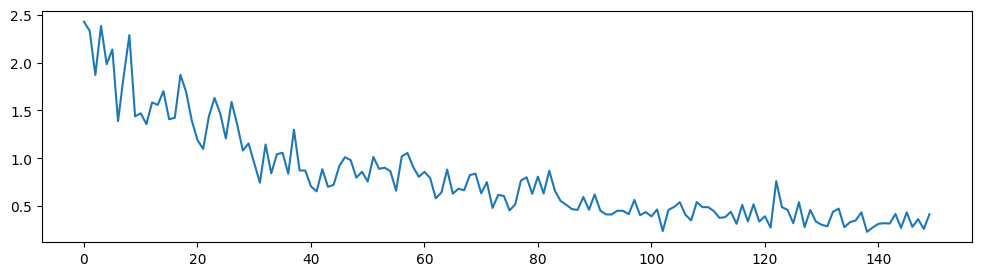

In [11]:
plt.figure(figsize=(12, 3))
plt.plot(losses)

# Submission

In [12]:
answers = []

for img in tqdm(test_loader):
    img = img.to(device)
    out = model(img).squeeze()
    answers.extend(out.cpu().tolist())

100%|██████████| 4/4 [00:01<00:00,  3.31it/s]


In [13]:
submission = pd.read_csv(f"{root_path}/test.csv")[["image_path"]]
submission["number"] = answers

submission.head()

,image_path,number
0,images/image_0119.png,0.298154
1,images/image_0227.png,-0.019249
2,images/image_0160.png,3.136380
3,images/image_0091.png,-0.023049
4,images/image_0141.png,5.251552


In [14]:
submission.to_csv(f"{root_path}/submission.csv", index=False)